In [2]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('netflix_data.csv')
df.head()

,show_id,type,title,director,cast,country,rating,release_year,date_added,duration,listed_in,description
0,s1,Movie,Title_1,David Fincher,"Song Kang, Leonardo DiCaprio",United States,TV-14,2014,"July 3, 2015",116 min,Comedies,This is a placeholder description for the show...
1,s2,TV Show,Title_2,David Fincher,"Shah Rukh Khan, Zendaya",United States,TV-MA,2013,"October 23, 2017",3 Seasons,TV Comedies,This is a placeholder description for the show...
2,s3,TV Show,Title_3,NaN,Shah Rukh Khan,United States,TV-14,2020,"July 3, 2023",3 Seasons,TV Comedies,This is a placeholder description for the show...
3,s4,Movie,Title_4,Martin Scorsese,"Shah Rukh Khan, Zendaya",United States,TV-MA,2010,"October 8, 2021",149 min,Action & Adventure,This is a placeholder description for the show...
4,s5,Movie,Title_5,David Fincher,"Millie Bobby Brown, Leonardo DiCaprio, Zendaya",India,R,2012,"July 5, 2021",121 min,Documentaries,This is a placeholder description for the show...


In [4]:
df.describe()

,release_year
count,5000.000000
mean,2017.218200
std,4.514717
min,1998.000000
25%,2014.000000
50%,2018.000000
75%,2021.000000
max,2023.000000


In [5]:
df.isnull().sum()

show_id           0
type              0
title             0
director        778
cast              0
country           0
rating            0
release_year      0
date_added        0
duration          0
listed_in         0
description       0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       5000 non-null   str  
 1   type          5000 non-null   str  
 2   title         5000 non-null   str  
 3   director      4222 non-null   str  
 4   cast          5000 non-null   str  
 5   country       5000 non-null   str  
 6   rating        5000 non-null   str  
 7   release_year  5000 non-null   int64
 8   date_added    5000 non-null   str  
 9   duration      5000 non-null   str  
 10  listed_in     5000 non-null   str  
 11  description   5000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 1.2 MB


In [7]:
# --- Enhanced Data Cleaning ---
# 1. Fix date formats and extract features
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['date_added'].dt.year

# 2. Handle missing values
# We know 'director' has np.nan from our generation step
df['director'] = df['director'].fillna('Unknown')

# 3. Remove duplicates (good practice, even with generated show_ids)
df = df.drop_duplicates()

# 4. Strip any accidental whitespace from text columns
text_cols = ['title', 'director', 'country', 'rating', 'listed_in']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print("Data cleaning complete. Ready for analysis.")



Data cleaning complete. Ready for analysis.


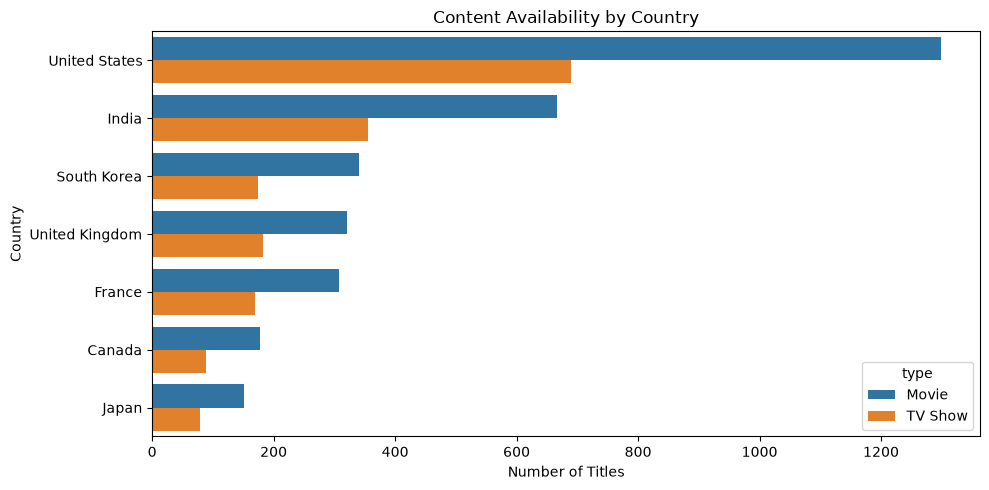

In [8]:
# 1. Content by Country 
plt.figure(figsize=(10, 5))
sns.countplot(y='country', hue='type', data=df, order=df['country'].value_counts().index)
plt.title('Content Availability by Country')
plt.xlabel('Number of Titles')
plt.ylabel('Country')  
plt.tight_layout()
plt.show()

In [9]:
country_type = df.groupby(['country', 'type']).size().reset_index(name='count')

country_type.head(10)

,country,type,count
0,Canada,Movie,177
1,Canada,TV Show,88
2,France,Movie,307
3,France,TV Show,170
4,India,Movie,667
5,India,TV Show,356
6,Japan,Movie,151
7,Japan,TV Show,79
8,South Korea,Movie,341
9,South Korea,TV Show,174


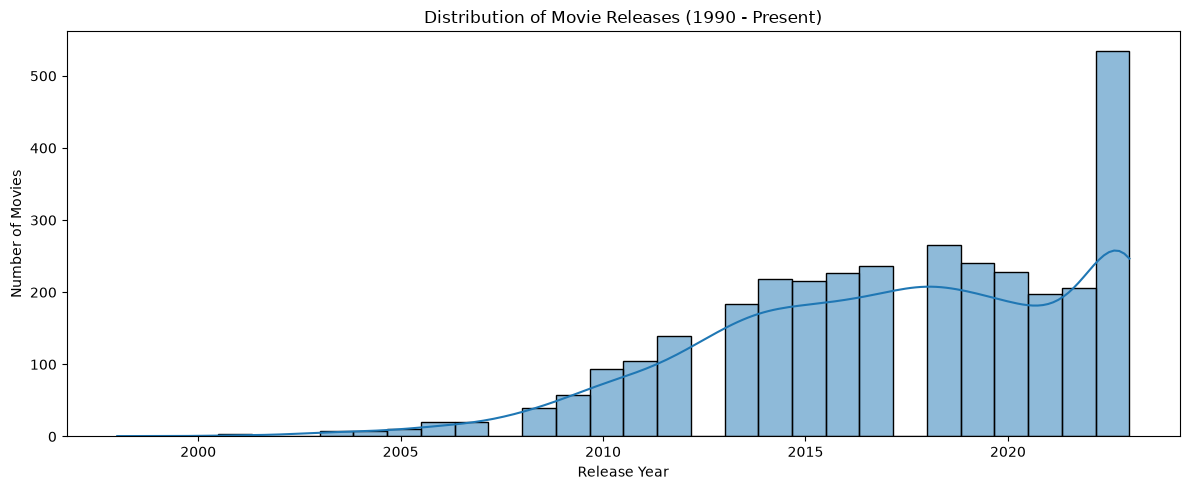

In [10]:
# 2. Movies Released Over the Last 30 Years
movies_df = df[df['type'] == 'Movie']
plt.figure(figsize=(12, 5))
sns.histplot(movies_df['release_year'], bins=30, kde=True)
plt.title('Distribution of Movie Releases (1990 - Present)')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

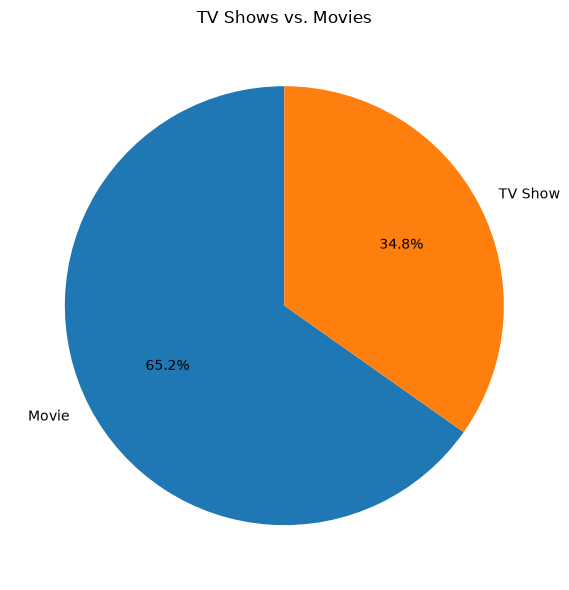

In [11]:
# 3. TV Shows vs. Movies Comparison
type_counts = df['type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('TV Shows vs. Movies')
plt.tight_layout()
plt.show()

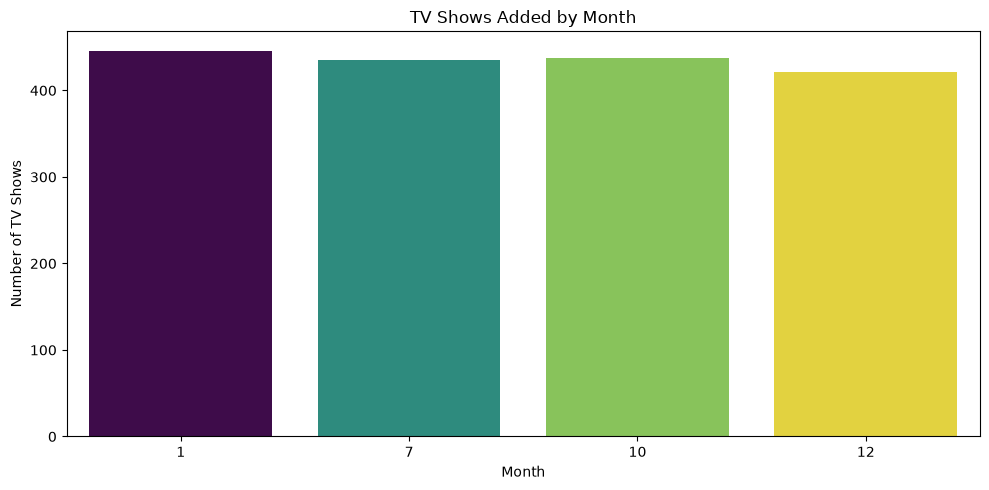

In [12]:
# 4. Best Time to Launch a TV Show
tv_df = df[df['type'] == 'TV Show']

plt.figure(figsize=(10, 5))

sns.countplot(
    x='month_added',
    data=tv_df,
    hue='month_added',
    palette='viridis',
    legend=False
)

plt.title('TV Shows Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of TV Shows')

plt.tight_layout()
plt.show()

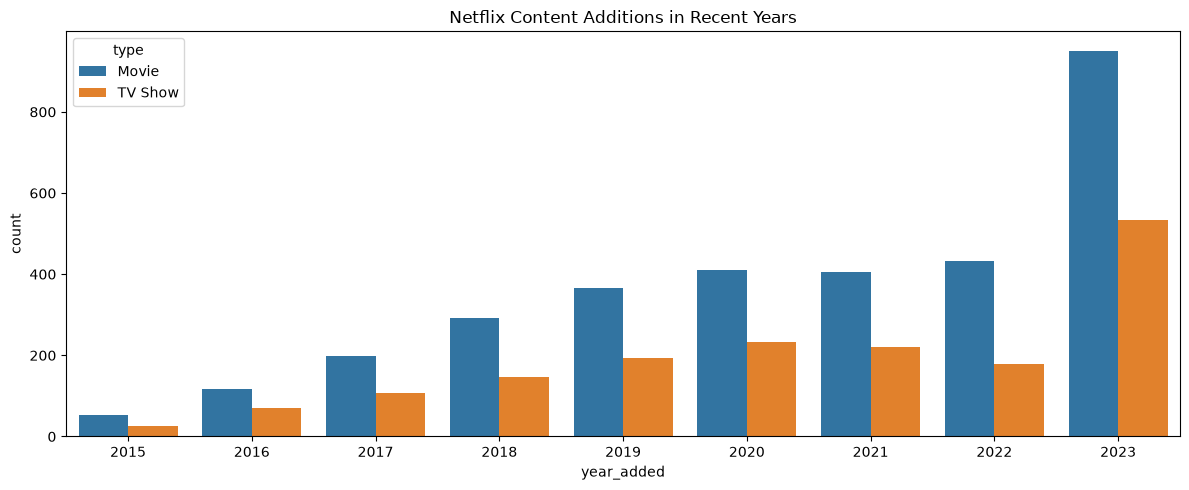

In [13]:
# 5. Recent Focus (TV Shows vs Movies over added years)
recent_df = df[df['year_added'] >= 2015]
plt.figure(figsize=(12, 5))
sns.countplot(x='year_added', hue='type', data=recent_df)
plt.title('Netflix Content Additions in Recent Years')
plt.tight_layout()
plt.show()